<center><font size="10">Business Statistics</font></center>
<center><b><font size="6" color="#1f4e79">Statistical Insights Supporting Business Decisions: E-news Express</font></b></center>

---
## **Business Context & Objective**

**Business Context**

E‑news Express is an online news portal aiming to increase subscriber acquisition. The company suspects that the **current landing page design is causing lower engagement and fewer new monthly subscribers**. To address this, a redesigned landing page was created with improved layout and more relevant content.

To evaluate its effectiveness, the Data Science team conducted an **A/B test**:

- **100 users** were randomly selected  
- Split into **control (old page)** and **treatment (new page)** groups  
- User interactions were recorded to assess engagement and conversion behavior  

The goal is to statistically determine whether the new landing page improves user engagement and subscription conversion.

---

**Objective**

Using the collected experiment data, perform statistical analysis (α = 0.05) to answer:

1. **Time on Page:** Do users spend more time on the new landing page compared to the old one?

2. **Conversion Rate:** Is the conversion proportion higher for the new page than for the old page?

3. **Language vs Conversion:**  Does conversion status depend on preferred language?  

4. **Time on Page vs Language:**  Is the time spent on the new page the same across different language groups?



---
## **Data Dictionary**

| Column | Description |
|--------|-------------|
| **user_id** | Unique ID for each website visitor |
| **group** | `control` (old page) or `treatment` (new page) |
| **landing_page** | Indicates whether the user saw the old or new page |
| **time_spent_on_the_page** | Time spent on the landing page (minutes) |
| **converted** | Whether the user subscribed (`yes`/`no`) |

---
## **Importing the necessary libraries**

In [1]:
# Import core libraries for data handling, visualization, and statistical tests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy.stats import ttest_ind, chi2_contingency, f_oneway
from statsmodels.stats.proportion import proportions_ztest

---
## **Loading the dataset**

In [2]:
# Load dataset
df = pd.read_csv("abtest.csv") 

print(f"shape of the dataset: {df.shape}")
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")

print("\n------------------------------\n")

display(df.head())
display(df.tail())

shape of the dataset: (100, 6)
Number of rows: 100, Number of columns: 6

------------------------------



,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


---
## **Data Overview**

In [ ]:
# ====================================
# Data overview and summary statistics
# ====================================

enews = df.copy() # creating a copy of the original dataset to work with

# view the shape of the dataset
print("Shape of the dataset:")
print( enews.shape)

print("\n------------------------------\n")

print("Data types of each column:")
print(enews.info() )

print("\n------------------------------\n")

# Statistical summary of the dataset
print("Summary statistics:")
display(enews.describe().T)


# ===============================
# Missing values and duplicate
# ===============================

# Count missing values in each column
print("=== MISSING VALUES ===")
display(enews.isnull().sum())

# Count duplicate rows
print("\n=== DUPLICATE ROWS ===")
print(enews.duplicated().sum())


Shape of the dataset:
(100, 6)

------------------------------

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB
None

------------------------------

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
user_id,100.0,546517.0000,52.295779,546443.00,546467.75,546492.500,546567.2500,546592.00
time_spent_on_the_page,100.0,5.3778,2.378166,0.19,3.88,5.415,7.0225,10.71


=== MISSING VALUES ===


user_id                   0
group                     0
landing_page              0
time_spent_on_the_page    0
converted                 0
language_preferred        0
dtype: int64


=== DUPLICATE ROWS ===
0


**Key Data Quality Observations**

- The dataset has **100 rows and 6 columns**, with **no missing values** and **no duplicated row**.
- There are **4 categorical** and **2 numerical** variables, suitable for proportion tests, t‑tests, chi‑square tests, and ANOVA.
- The average time spent on the page is **5.38 minutes**, with a standard deviation of **2.38 minutes**, indicating moderate variability.
- Time spent ranges from **0.19 to 10.71 minutes**, showing both very low and very high engagement.
- The median (5.41) is close to the mean (5.38), suggesting a roughly symmetric distribution.
- Most users spend **between 4 and 7 minutes** on the landing page (IQR).
- `user_id` is an identifier and not relevant for statistical analysis.


---
## **Exploratory Data Analysis**

In [4]:
# Standardise column names by stripping whitespace from the headers  

enews.columns = [c.strip() for c in enews.columns]
enews.columns

Index(['user_id', 'group', 'landing_page', 'time_spent_on_the_page',
       'converted', 'language_preferred'],
      dtype='object')

In [5]:
# Select numerical and categorical columns dynamically and exclude any column whose name contains 'id'

num_cols = [
    col for col in enews.select_dtypes(include=['int64', 'float64']).columns
    if 'id' not in col.lower()
]


cat_cols = enews.select_dtypes(include='object').columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

time_spent = "time_spent_on_the_page"  # set the target variable for bivariate analysis

Numerical Columns: ['time_spent_on_the_page']
Categorical Columns: Index(['group', 'landing_page', 'converted', 'language_preferred'], dtype='object')


### EDA Utility Function

In [6]:
# Custom EDA function to plot numeric distributions and categorical countplots in a grid format

def plot_numeric_and_categorical_eda(df, numeric_cols, categorical_cols):
    """
    Generates:
      1. Numeric Histograms + Boxplots (with median annotation + outlier count)
      2. Categorical Countplots (grid)
    """

    sns.set(style="whitegrid")

    # ============================================================
    # 1. NUMERIC DISTRIBUTIONS (Histogram + Boxplot + Outlier Count)
    # ============================================================
    n_cols = 2   # histogram + boxplot
    n_rows = len(numeric_cols)

    plt.figure(figsize=(14, n_rows * 4))
    plt.suptitle("Numeric Distributions (Histogram + Boxplot + Outlier Count)", fontsize=16, y=1.02)

    for i, col in enumerate(numeric_cols):
        median_val = df[col].median()

        # Histogram
        ax1 = plt.subplot(n_rows, n_cols, 2*i + 1)
        sns.histplot(df[col], kde=True, ax=ax1)
        ax1.axvline(median_val, color='red', linestyle='--', linewidth=1.5)
        ax1.text(median_val, ax1.get_ylim()[1]*0.9,
                 f"Median = {median_val:.2f}",
                 color='red', ha='center', fontsize=9)
        ax1.set_title(f"Distribution of {col}")

        # Boxplot
        ax2 = plt.subplot(n_rows, n_cols, 2*i + 2)
        sns.boxplot(x=df[col], ax=ax2)
        ax2.axvline(median_val, color='red', linestyle='--', linewidth=1.5)
        ax2.text(median_val, ax2.get_ylim()[0],
                 f"{median_val:.2f}",
                 color='red', ha='center', va='bottom', fontsize=9)
        ax2.set_title(f"Boxplot of {col}")

        # ---- IQR Outlier Calculation ----
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

        # ---- Add outlier count below boxplot ----
        ax2.text(
            0.5, -0.25,
            f"Outliers: {outlier_count}",
            ha="center", va="center",
            transform=ax2.transAxes,
            fontsize=10, color="red"
        )

    plt.tight_layout()
    plt.show()

    # ============================================================
    # 2. CATEGORICAL COUNTPLOTS (Grid)
    # ============================================================
    n_cols = 2
    n_rows = math.ceil(len(categorical_cols) / n_cols)

    plt.figure(figsize=(18, n_rows * 4))
    plt.suptitle("Categorical Variable Countplots", fontsize=16, y=1.02)

    for i, col in enumerate(categorical_cols, 1):
        ax = plt.subplot(n_rows, n_cols, i)

        order = df[col].value_counts().index
        counts = df[col].value_counts()
        total = len(df)

        sns.countplot(y=df[col], order=order, ax=ax)
        ax.set_title(f"Countplot of {col}")

        # ---- Add percentage labels ----
        for idx, value in enumerate(counts):
            pct = (value / total) * 100
            ax.annotate(
                f"{pct:.1f}%",
                xy=(value, idx),
                xytext=(5, 0),
                textcoords="offset points",
                va="center",
                fontsize=10
            )

    plt.tight_layout()
    plt.show()




In [7]:
#  Custom EDA function to plot relationships between target and categorical variables in a grid format

def plot_target_relationships_c(df, categorical_cols, target_col):
    """
    Categorical bivariate analysis:
    - Horizontal boxplot with mean annotation
    - Horizontal sales contribution %
    - 2 categorical variables per row
    """

    sns.set(style="whitegrid")

    total_sales = df[target_col].sum()
    rows = math.ceil(len(categorical_cols) / 2)

    fig, axes = plt.subplots(
        rows,
        4,
        figsize=(20, 4.5 * rows)
    )

    axes = axes.reshape(rows, 4)

    for idx, col in enumerate(categorical_cols):

        row = idx // 2
        start_col = 0 if idx % 2 == 0 else 2

        box_ax = axes[row, start_col]
        bar_ax = axes[row, start_col + 1]

        # Summary
        means = df.groupby(col)[target_col].mean().sort_values()
        sales_pct = (
            df.groupby(col)[target_col]
            .sum()
            .sort_values()
            / total_sales
            * 100
        )

        # Horizontal boxplot
        sns.boxplot(
            data=df,
            y=col,
            x=target_col,
            order=means.index,
            ax=box_ax
        )

        for pos, val in enumerate(means):
            box_ax.text(
                val,
                pos,
                f" {val:,.0f}",
                va="center",
                color="red",
                fontsize=8,
                fontweight="bold"
            )

        box_ax.set_title(f"{col} - Time spent on the Page", fontsize=10)
        box_ax.set_xlabel("Time Spent")
        box_ax.set_ylabel("")

        # Horizontal contribution chart
        sns.barplot(
            x=sales_pct.values,
            y=sales_pct.index,
            ax=bar_ax
        )

        for pos, val in enumerate(sales_pct.values):
            bar_ax.text(
                val,
                pos,
                f" {val:.1f}%",
                va="center",
                fontsize=8
            )

        bar_ax.set_title(f"{col} - Time spent on the Page", fontsize=10)
        bar_ax.set_xlabel("% Time Spent")
        bar_ax.set_ylabel("")

    # Hide unused axes
    used_axes = len(categorical_cols) * 2
    for ax in axes.flatten()[used_axes:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Univariate Analysis

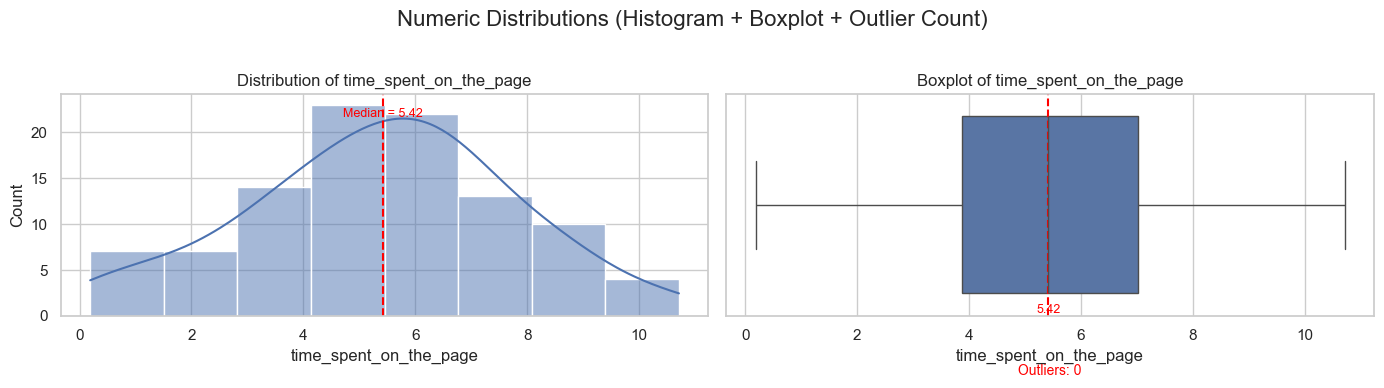

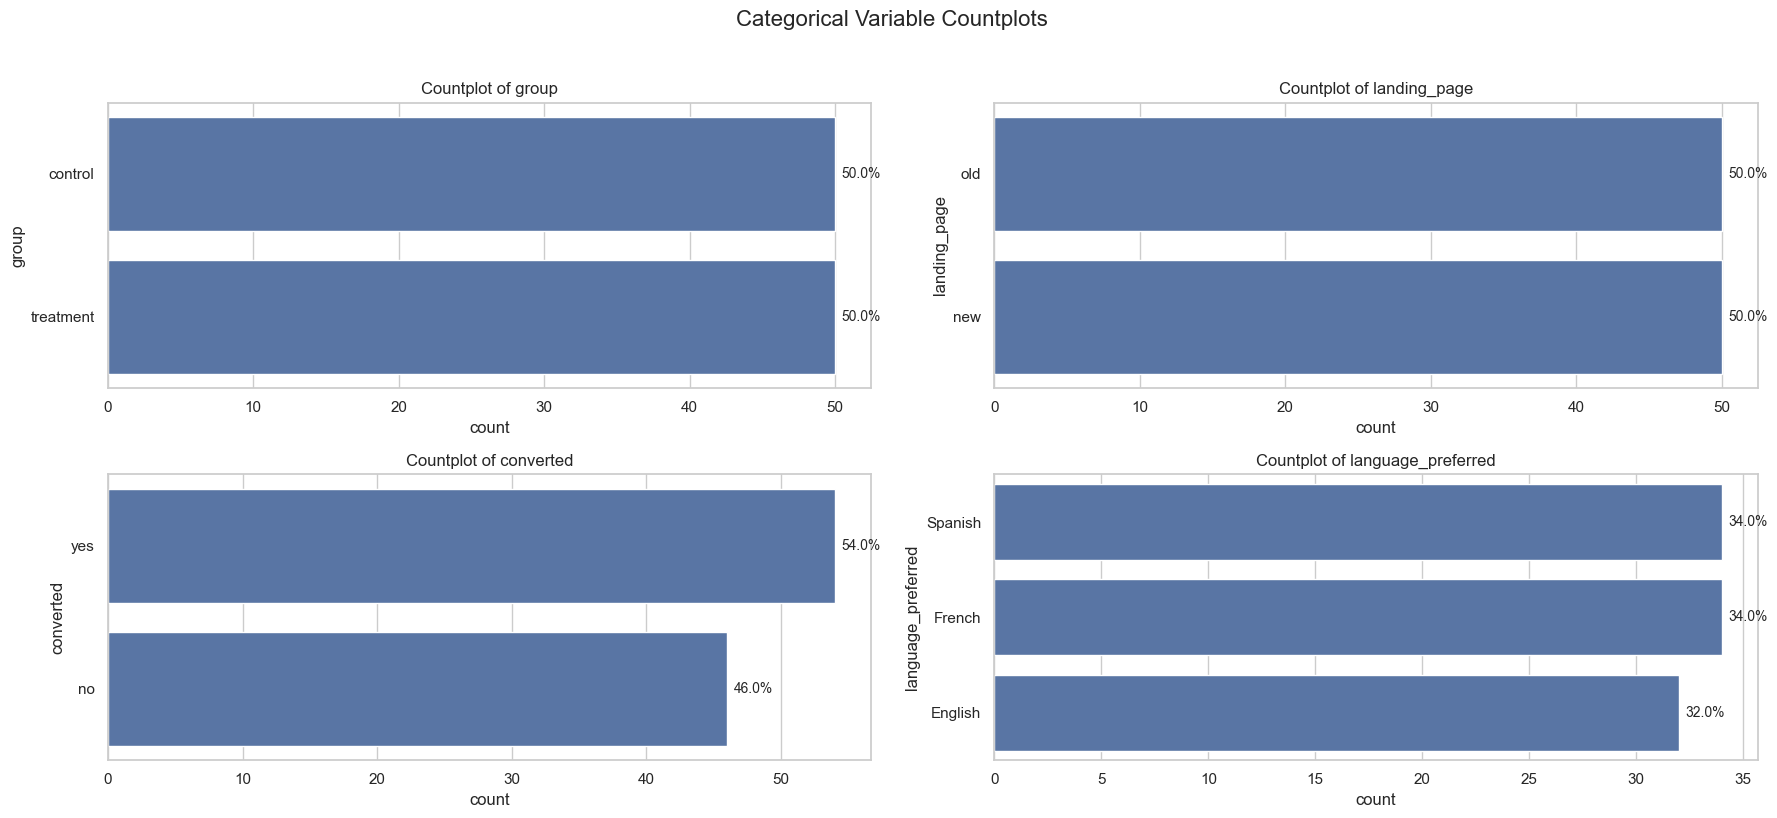

In [8]:
# Call the EDA plotting function
plot_numeric_and_categorical_eda(enews, num_cols, cat_cols)  


**Observations**

**Numeric Variable — `time_spent_on_the_page`**
- Distribution is **smooth, unimodal, and symmetric**, indicating stable user behavior.  
- **Median ≈ 5.42** aligns with mean → **no skew**.  
- **No outliers** detected → consistent engagement across users.  
- Time ranges from **0.19 to 10.71 minutes**, showing **wide variability**.  
- Majority of users fall within **4–7 minutes**, the core engagement band.  
- Spread suggests **mixed engagement intensity** across the sample.


**Categorical Variables**
- **Group** distribution is perfectly balanced (**50% control**, **50% treatment**).  
- **Landing page** exposure is also balanced (**50% old**, **50% new**).  
- **Conversion** slightly favors “yes” (**54%**) over “no” (**46%**).  
- **Language** distribution is nearly uniform (Spanish 34%, French 34%, English 32%).  
- Balanced categories → strong foundation for **fair comparison** across groups.

### Bivariate Analysis

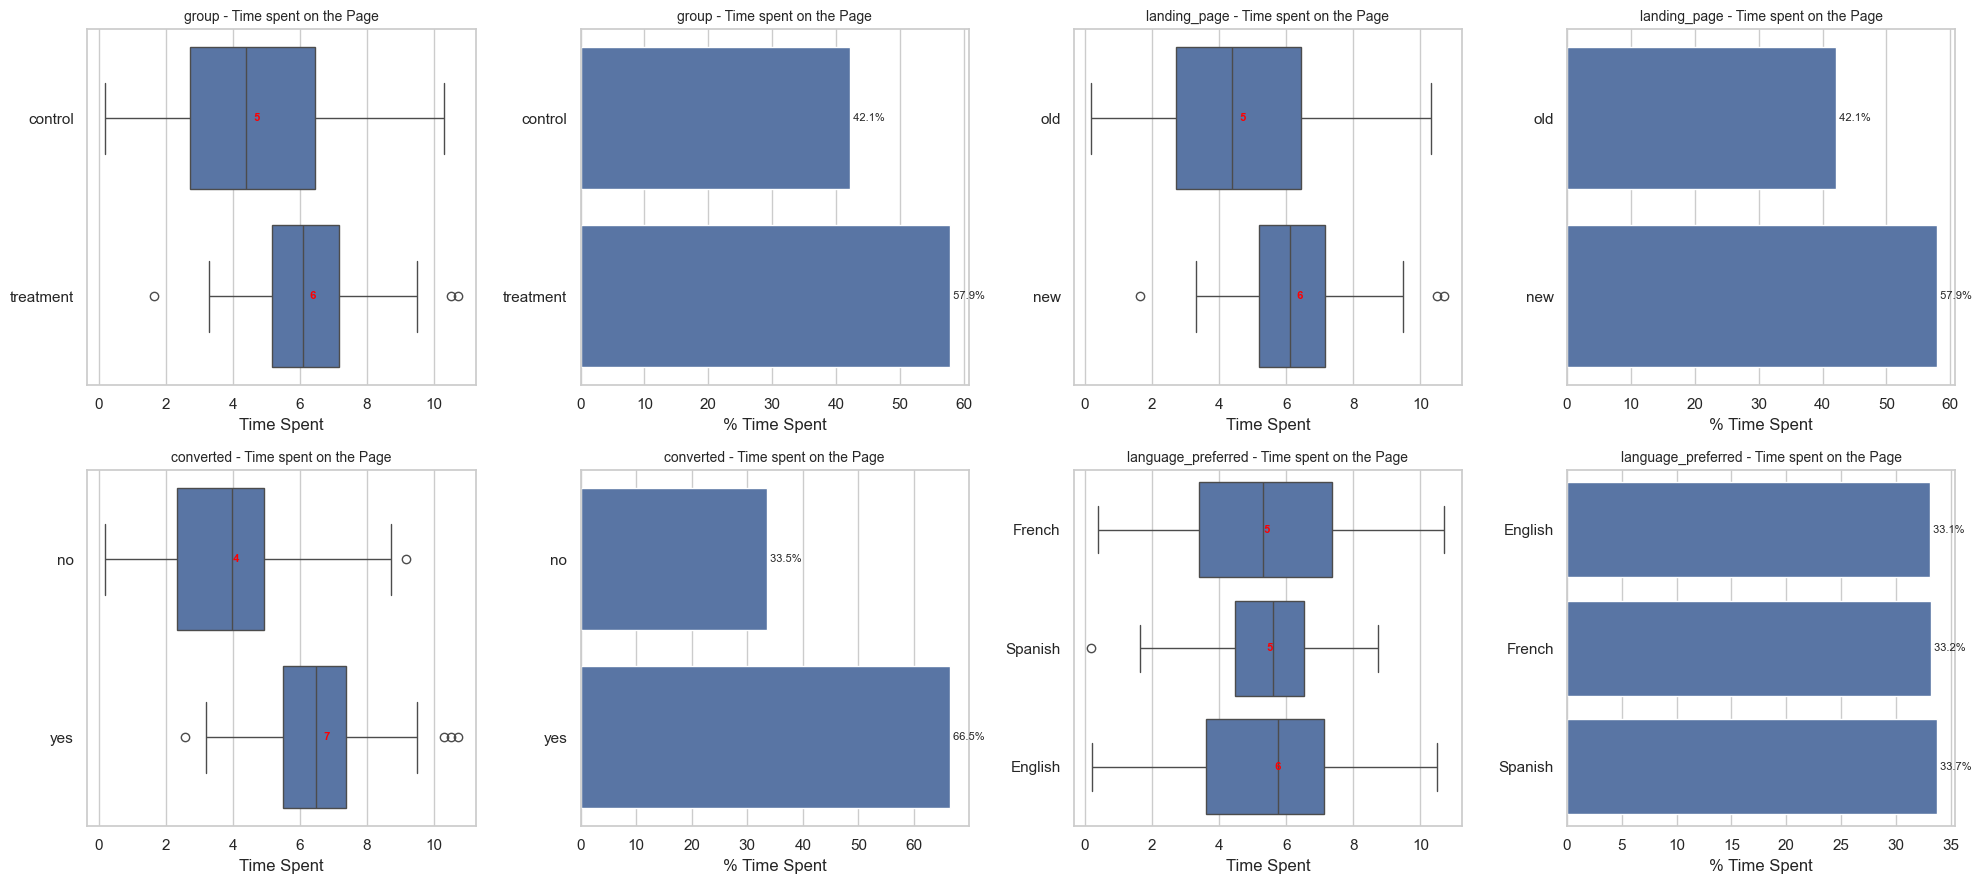

In [9]:
plot_target_relationships_c(
    df=enews,
    target_col=time_spent, 
    categorical_cols=cat_cols
)

**Observations**

**Time Spent vs Group**
- **Treatment group shows higher median time (≈6 min)** than control (≈5 min).  
- Distribution suggests **treatment users engage slightly more**.  
- Bar proportions (42.1% vs 57.9%) indicate **more high‑time users in treatment**.

 **Time Spent vs Landing Page**
- **New page users spend more time (median ≈6 min)** than old page users (≈5 min).  
- Engagement is **consistently higher** on the new page.  
- Bar proportions mirror group distribution (42.1% vs 57.9%), reinforcing **higher engagement on new page**.

**Time Spent vs Conversion**
- **Converted users spend much more time (median ≈7 min)** than non‑converted users (≈4 min).  
- Strong positive relationship between **time spent and likelihood of conversion**.  
- Bar proportions (66.5% yes vs 33.5% no) show **high‑time users convert more frequently**.

**Time Spent vs Language**
- Median times: **English ≈6**, French ≈5, Spanish ≈5.  
- English users show **slightly higher engagement**.  
- Language proportions are nearly equal (≈33% each), ensuring **balanced comparison**.  
- Differences are present but **not large**, suggesting **minor language‑based variation**.


**EDA‑Driven Motivation for Statistical Testing**

- The exploratory analysis reveals clear patterns in user engagement across different segments of the dataset. The distribution of *time_spent_on_the_page* is smooth, symmetric, and free of outliers, indicating reliable and stable behavior suitable for mean‑based comparisons. 
- Visual comparisons show that users in the treatment group and those exposed to the new landing page tend to spend more time on the page, suggesting potential differences in engagement worth formally testing. 
- Conversion behavior also aligns with time spent: converted users exhibit noticeably higher median engagement, and the conversion distribution itself shows a slight imbalance toward “yes,” motivating a deeper statistical comparison of conversion rates between landing pages. 
- The categorical distributions for preferred language are balanced, allowing unbiased evaluation of whether conversion varies across languages. Additionally, small but visible differences in median time spent across language groups for new‑page users indicate that language may play a role in engagement. 

*Together, these visuals highlight meaningful patterns and justify the use of formal hypothesis testing to determine whether the observed differences are statistically significant.*


---
## **Objective‑Based Inferential Analysis**

### **1. Do the users spend more time on the new landing page than the existing landing page?**

#### **<span style="color:#1f4e79;font-size:20px;">Visual Analysis</span>**

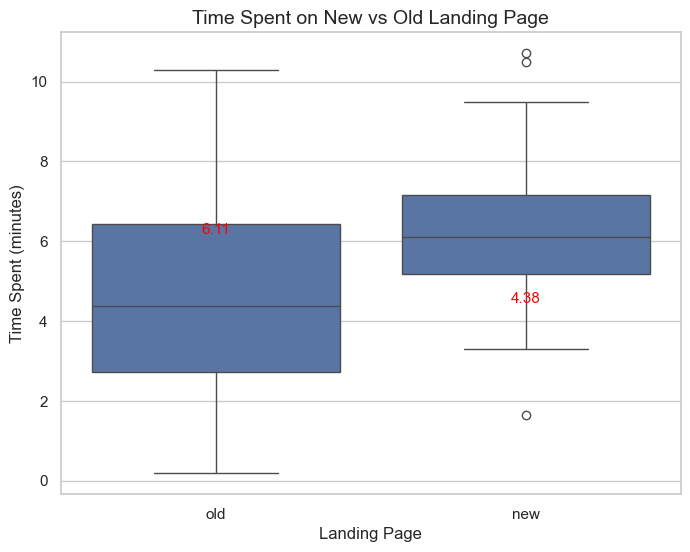

In [10]:
# visual analysis of the time spent on the new page and the time spent on the old page

plt.figure(figsize=(8,6))
sns.boxplot(x='landing_page', y=time_spent, data=enews)
plt.title("Time Spent on New vs Old Landing Page", fontsize=14)
medians = enews.groupby('landing_page')[time_spent].median()

for i, median in enumerate(medians):
    plt.text(i, median, f"{median:.2f}", 
             ha='center', va='bottom', color='red', fontsize=11)

plt.xlabel("Landing Page")
plt.ylabel("Time Spent (minutes)")
plt.show()


**Observations (Time Spent: New vs Old Landing Page)**

- Users on the **new landing page spend more time** on average, with a visibly higher median.  
- The **old page shows lower central tendency** and wider spread, indicating more variability in engagement.  
- The new page’s distribution is **more compact**, suggesting more consistent user interaction.  
- Presence of a few outliers on both pages indicates **individual extreme behaviors**, but not enough to distort the overall pattern.  
- The difference in central values (median/mean) suggests **potential improvement in engagement** on the new page.

***A formal hypothesis test is required to determine whether the observed difference in time spent between the new and old landing pages is **statistically significant** rather than due to random variation.***

#### **<span style="color:#1f4e79;font-size:20px;">Hypothesis Testing</span>**

**1. H₀ (Null):** 
The mean time spent on the new landing page is equal to the mean time spent on the old landing page.
$
H_0: \mu_{\text{new}} = \mu_{\text{old}}
$

**Hₐ (Alternative):** 
Users spend more time on the new landing page.
$
H_a: \mu_{\text{new}} > \mu_{\text{old}}
$

**2. Appropriate test:**
- This is a **one‑tailed test** comparing the mean time spent between two **independent groups (new vs old landing page).** The variable (**time spent) is continuous**, and the population standard deviations are unknown.
- **Based on this information, the appropriate test is a right‑tailed independent two‑sample t‑test.**

**3. Significance Level :**
As given in the problem statement, we select $\alpha = 0.05$ as standard.


#### **<span style="color:#1f4e79;font-size:20px;">Pre‑Analysis Data Processing and P‑Value Computation</span>**

In [11]:
# create subsetted data frame for new landing page users
time_spent_new = df[df['landing_page'] == 'new'][time_spent]

# create subsetted data frame for old landing page users
time_spent_old = df[df['landing_page'] == 'old'][time_spent]

print('The sample standard deviation of the time spent on the new page is:', round(time_spent_new.std(),2))
print('The sample standard deviation of the time spent on the old page is:', round(time_spent_old.std(),2))

The sample standard deviation of the time spent on the new page is: 1.82
The sample standard deviation of the time spent on the old page is: 2.58


**Observation**
- From the sample standard deviations (1.82 for the new page and 2.58 for the old page), their ratio is about 1.42, which is less than 2, so the variability between the two groups is not drastically different.
- Therefore, it is reasonable to assume equal population variances and use a pooled‑variance independent two‑sample t‑test, with a one‑sided (right‑tailed) alternative because we are testing if the new page has greater mean time.

In [12]:
# Calculate the p-value

test_stat, p_value = ttest_ind(
    time_spent_new,
    time_spent_old,
    equal_var = True,        # assume equal variances based on similar sample SDs
    alternative = 'greater'  # one-tailed test: new page > old page
)

print('The p-value is', p_value)


The p-value is 0.00013161235280950077


####  **<span style="color:#1f4e79;font-size:20px;">Significance Testing: p‑Value vs α</span>**

In [ ]:
# Compare the p-value with α and Draw Inference

if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
    print("Inference: Users spend significantly more time on the new landing page. The new design increases user engagement.")
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')
    print("Inference: There is no statistical evidence that users spend more time on the new landing page.")

As the p-value 0.00013161235280950077 is less than the level of significance, we reject the null hypothesis.
Inference: Users spend significantly more time on the new landing page. The new design increases user engagement.


### **2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?**

#### **<span style="color:#1f4e79;font-size:20px;">Visual Analysis</span>**

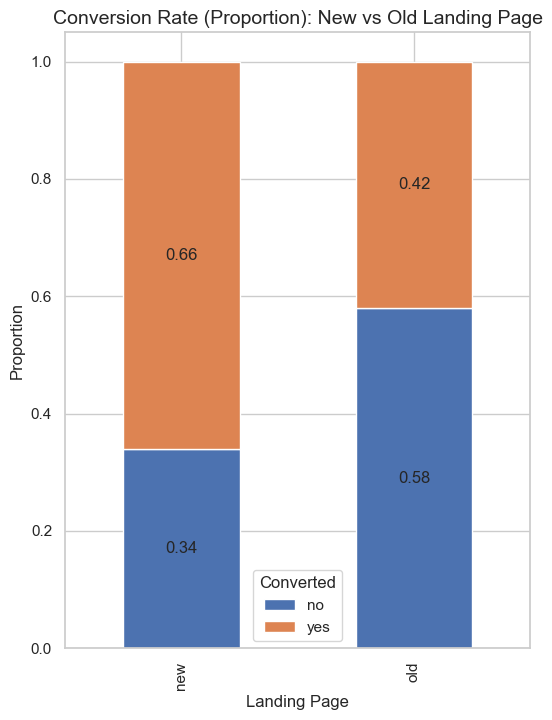

In [14]:
# Visualize the conversion rate (proportion) for new vs old landing page

plt.figure(figsize=(6,8))
ax = pd.crosstab(enews['landing_page'],   enews['converted'],  normalize='index' ).plot(kind="bar", stacked=True, figsize=(6,8), ax=plt.gca())
plt.title("Conversion Rate (Proportion): New vs Old Landing Page", fontsize=14)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type='center')
plt.xlabel("Landing Page")
plt.ylabel("Proportion")
plt.legend(title="Converted")
plt.show()


** Observations (Proportion‑Based Conversion Rates)**

- The **new landing page shows a higher proportion of conversions**, indicating stronger user engagement compared to the old page.  
- The **old landing page has a larger proportion of non‑converters**, suggesting it is less effective at driving user action.  
- The difference in conversion proportions between the two pages is **visually clear**, with the new page showing a noticeably larger “yes” segment.

***A hypothesis test is needed to determine whether the observed difference in conversion proportions between the new and old landing pages is statistically meaningful rather than due to chance.***

#### **<span style="color:#1f4e79;font-size:20px;">Hypothesis Testing</span>**

**1. H₀ (Null):** 
The conversion rate for the new landing page is equal to the conversion rate for the old landing page.
$
H_0: \mu_{\text{new}} = \mu_{\text{old}}
$

**Hₐ (Alternative):** 
The conversion rate for the new landing page is higher.
$
H_a: \mu_{\text{new}} > \mu_{\text{old}}
$

**2. Appropriate test:**
- This is a o**ne‑tailed test comparing two population proportions (conversion rates) from two independent groups** (new vs old landing page).
- **Based on this information, the appropriate test is a right‑tailed two‑sample proportions z‑test.**

**3. Significance Level :**
As given in the problem statement, we select $\alpha = 0.05$ as standard.


#### **<span style="color:#1f4e79;font-size:20px;">Pre‑Analysis Data Processing and P‑Value Computation</span>**

In [15]:
# Collect data for the z-test for proportions

new_converted = enews[enews['group'] == 'treatment']['converted'].value_counts()['yes'] # number of converted users in the treatment group
old_converted = enews[enews['group'] == 'control']['converted'].value_counts()['yes'] # number of converted users in the control group

n_control = enews['group'].value_counts()['control'] # total number of users in the control group
n_treatment = enews['group'].value_counts()['treatment'] # total number of users in the treatment group

print('The numbers of users served the new and old pages are {0} and {1} respectively'.format(n_control, n_treatment ))

The numbers of users served the new and old pages are 50 and 50 respectively


In [16]:
# Calculate the p-value for the one-tailed test (new page > old page)

test_stat, p_value = proportions_ztest(
    [new_converted, old_converted],
    [n_treatment, n_control],
    alternative='larger'   # one-tailed: p_new > p_old
)

print('The p-value is', p_value)
    

The p-value is 0.008026308204056278


####  **<span style="color:#1f4e79;font-size:20px;">Significance Testing: p‑Value vs α</span>**

In [ ]:
# Compare the p-value with α and Draw Inference

if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
    print("Inference: The conversion rate is significantly higher for the new landing page.")
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')
    print("Inference: There is no statistical evidence that the new landing page has a higher conversion rate.")

As the p-value 0.008026308204056278 is less than the level of significance, we reject the null hypothesis.
Inference: The conversion rate is significantly higher for the new landing page.


### **3. Is the conversion and preferred language independent or related?**

#### **<span style="color:#1f4e79;font-size:20px;">Visual Analysis</span>**

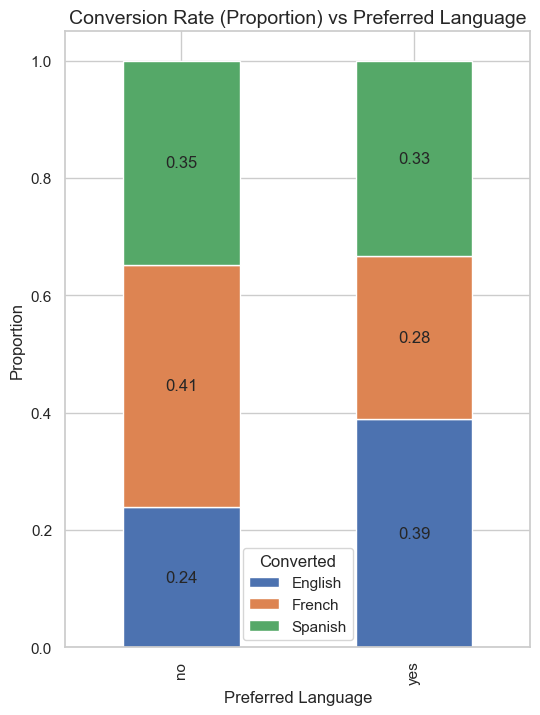

In [18]:
# Visualize the conversion rate (proportion) for new vs preferred language

plt.figure(figsize=(6,8))
ax = pd.crosstab(enews['converted'],   enews['language_preferred'],  normalize='index' ).plot(kind="bar", stacked=True, figsize=(6,8), ax=plt.gca())
plt.title("Conversion Rate (Proportion) vs Preferred Language", fontsize=14)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type='center')
plt.xlabel("Preferred Language")
plt.ylabel("Proportion")
plt.legend(title="Converted")
plt.show()

**Observations (Proportion‑Based Conversion vs Preferred Language)**

- Users who prefer **English** show a higher conversion proportion compared to French and Spanish, indicating stronger engagement within this language group.  
- The **French‑preferred group** has a noticeably larger non‑conversion proportion, suggesting lower effectiveness in driving conversions.  
- The **Spanish‑preferred group** shows relatively balanced proportions between converters and non‑converters, indicating moderate responsiveness.


***A hypothesis test is required likewise to determine whether the differences in conversion proportions across preferred language groups are statistically significant rather than due to random variation.***

#### **<span style="color:#1f4e79;font-size:20px;">Hypothesis Testing</span>**

**1. H₀ (Null):** 
Conversion is independent of language.
$
H_0: \text{Conversion is independent of language}
$

**Hₐ (Alternative):** 
Conversion depends on language.
$
H_a: \text{Conversion is dependent on language}
$

**2. Appropriate test:**
- This is a test of independence between two categorical variables (preferred language and conversion outcome).
- **Based on this information, the appropriate test is a Chi‑square test of independence..**

**3. Significance Level :**
As given in the problem statement, we select $\alpha = 0.05$ as standard.


#### **<span style="color:#1f4e79;font-size:20px;">Pre‑Analysis Data Processing and P‑Value Computation</span>**

In [19]:
# Contingency table of language vs conversion
ct = pd.crosstab(enews['language_preferred'], enews['converted'])
print(ct)

# Calculate the chi-square statistic and p-value for the contingency table
chi2, p_value, dof, expected = chi2_contingency(ct)

# print the chi-square statistic and p-value

print('Chi-square statistic:', chi2)
print('The p-value is', p_value)

converted           no  yes
language_preferred         
English             11   21
French              19   15
Spanish             16   18
Chi-square statistic: 3.0930306905370832
The p-value is 0.21298887487543453


**Observations (Contingency Table + Chi‑Square Output)**

- The **conversion proportions differ across languages**, with English showing more conversions (21/32) than French (15/34) and Spanish (18/34).  
- The **observed counts deviate from the expected counts**, but not strongly enough to produce a large chi‑square statistic (χ² ≈ 3.09).  
- The **p‑value of 0.213** is relatively high, indicating that the variation in conversion counts across languages is **not substantial** in statistical terms.

####  **<span style="color:#1f4e79;font-size:20px;">Significance Testing: p‑Value vs α</span>**

In [20]:
# Compare the p-value with α and Draw Inference

if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
    print("Inference: Conversion depends on language. There is a significant association between preferred language and conversion.")
else:
    print(f'Since p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')
    print("Inference: Conversion does not depend on language. No significant association between preferred language and conversion.")

Since p-value 0.21298887487543453 is greater than the level of significance, we fail to reject the null hypothesis.
Inference: Conversion does not depend on language. No significant association between preferred language and conversion.


### **4. Is the time spent on the new page same for the different language users?**

#### **<span style="color:#1f4e79;font-size:20px;">Visual Analysis</span>**

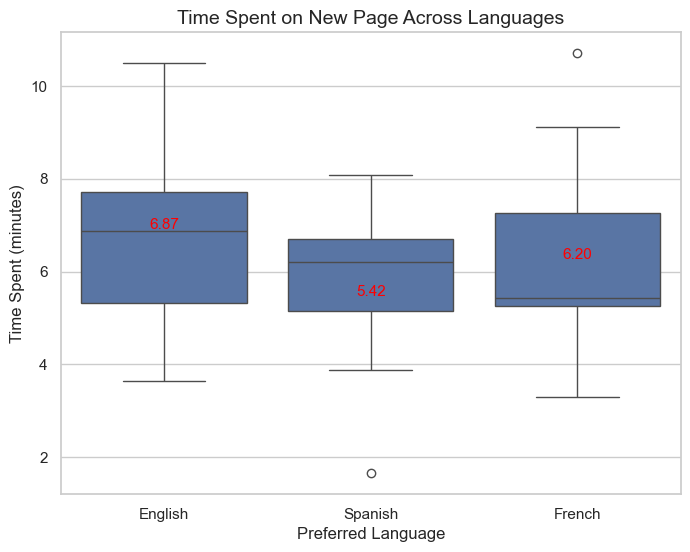

language_preferred
English    6.663750
French     6.196471
Spanish    5.835294
Name: time_spent_on_the_page, dtype: float64

In [21]:
# Filter only new landing page users
new_df = enews[enews['landing_page'] == 'new']

# visual analysis of the time spent on the new page and the time spent on the old page
plt.figure(figsize=(8,6))
sns.boxplot(x='language_preferred', y=time_spent, data=new_df)
plt.title("Time Spent on New Page Across Languages", fontsize=14)

# Correct median calculation
medians = new_df.groupby('language_preferred')[time_spent].median()

for i, median in enumerate(medians):
    plt.text(i, median, f"{median:.2f}",
             ha='center', va='bottom', color='red', fontsize=11)

plt.xlabel("Preferred Language")
plt.ylabel("Time Spent (minutes)")
plt.show()

# mean time spent on the new page for different language users
new_df.groupby(['language_preferred'])['time_spent_on_the_page'].mean()


**Observations (Time Spent on New Page by Language)**

- **English‑preferred users spend the most time** on the new landing page, indicating stronger engagement compared to French and Spanish users.  
- **Spanish‑preferred users consistently show the lowest time spent**, suggesting weaker interaction with the new page’s content.  
- The **spread and presence of outliers differ across languages**, implying variability in how users from each language group interact with the new page.

***A hypothesis test is required to determine whether the differences in mean time spent across language groups are statistically significant rather than due to random variation.***


#### **<span style="color:#1f4e79;font-size:20px;">Hypothesis Testing</span>**

**1. H₀ (Null):** 
Mean time spent on the new page is equal across all languages.
$
H_0: \mu_1 = \mu_2 = \mu_3 = \dots
$

**Hₐ (Alternative):** 
At least one language group has a different mean time spent.
$
H_a: \text{At least one } \mu_i \text{ differs}
$

**2. Appropriate test:**
- This is a test comparing mean time spent across more than two independent groups (languages), with a continuous response variable (time spent). 
- **Based on this information, the appropriate test is a one‑way ANOVA.**


**3. Significance Level :**
As given in the problem statement, we select $\alpha = 0.05$ as standard.

#### **<span style="color:#1f4e79;font-size:20px;">Pre‑Analysis Data Processing and P‑Value Computation</span>**

In [22]:
# Build list of time-spent groups by language (new page only)
groups = [
    new_df[new_df['language_preferred'] == lang][time_spent].values
    for lang in new_df['language_preferred'].unique()
]

print('Languages:', new_df['language_preferred'].unique())



f_stat, p_value = f_oneway(*groups)

print('F-statistic:', f_stat)
print('The p-value is', p_value)


Languages: ['English' 'Spanish' 'French']
F-statistic: 0.854399277000682
The p-value is 0.43204138694325916


**Observations (ANOVA: Time Spent on New Page Across Languages)**

- The **F‑statistic is very small (≈0.85)**, indicating that the variation in mean time spent across English, French, and Spanish users is minimal relative to the variation within each group.  
- The **mean times are close together** (English ≈ 6.66, French ≈ 6.20, Spanish ≈ 5.84), showing no strong separation between language groups in how long they spend on the new page.  
- The **p‑value of 0.432** is high, suggesting that any observed differences in mean time spent are likely due to random variation rather than a systematic effect of preferred language.

####  **<span style="color:#1f4e79;font-size:20px;">Significance Testing: p‑Value vs α</span>**

In [24]:
# Compare the p-value with α and Draw Inference

if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
    print("Inference: Time spent on the new landing page differs significantly across languages.")
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')
    print("Inference: Preferred language does not significantly influence the time users spend on the new page.")


As the p-value 0.43204138694325916 is greater than the level of significance, we fail to reject the null hypothesis.
Inference: Preferred language does not significantly influence the time users spend on the new page.


---
## **Conclusion and Business Recommendations**

<span style="color:#1f4e79;font-size:25px;">Conclusion</span>

- The statistical evaluation of user behaviour across the four experimental objectives provides a clear and evidence‑driven understanding of the new landing page’s performance. The hypothesis tests reveal a mixed pattern: users do spend significantly more time on the new landing page (p ≈ 0.00013), and the conversion rate is significantly higher for the new page (p ≈ 0.0080). These results indicate that the new design successfully increases both engagement and conversion.

- However, language‑based analyses show no statistically meaningful differences. The chi‑square test (p ≈ 0.2130) demonstrates that conversion does not depend on preferred language, and the ANOVA test (p ≈ 0.4320) confirms that preferred language does not significantly influence time spent on the new page. These findings suggest that the new landing page performs consistently across language groups, without favouring or disadvantaging any particular segment.

- Taken together, the results indicate that the new landing page provides measurable performance gains in both engagement and conversion, while maintaining stable behaviour across language preferences. The statistical evidence supports adopting the new landing page as a more effective design for driving user action and improving overall platform performance.<br><br>


<span style="color:#1f4e79; font-size:25px;">Business Recommendations</span>

- Deploy the new landing page, as it significantly improves both user engagement and conversion rate compared to the existing design.

- Leverage the consistent performance across languages by maintaining a unified landing page experience without segment‑specific variations.

- Conduct follow‑up A/B tests focusing on micro‑optimisations (headline clarity, call‑to‑action placement, form simplicity) to further amplify the gains already observed.

- Monitor behavioural metrics over time to ensure the uplift in engagement and conversion remains stable as user traffic and demographics evolve.

- Complement quantitative insights with qualitative feedback, such as short user surveys or session recordings, to understand which elements of the new design most effectively drive user action.


___
##